# YDFA modular model (uω-driven PSD)

This notebook rewrites the YDFA setup so all model variables live in a single parameter container `p`.

Key change vs `YDFA.ipynb`:
- the ODE state is `[Pp, Ps]` (pump power + total signal power),
- the spectral signal shape is provided by `p.uω`,
- the power spectral density is recomputed during every ODE evaluation from `p.uω`.

Because `p` is mutable, you can update `p.uω` during the solve (e.g., via callbacks).


In [1]:
using Interpolations
using Revise
using Printf
using LinearAlgebra
using PyPlot
using FFTW
using MultiModeNoise
using DifferentialEquations


In [2]:
# --- Physical constants ---
const h = 6.62607015e-34
const c = 2.99792458e8

# --- Simulation grid for signal spectrum ---
λ0 = 1030e-9
M = 1
Nt = 2^12
time_window = 10 # ps
β_order = 2
sim = MultiModeNoise.get_disp_sim_params(λ0, M, Nt, time_window, β_order)

# --- Seed field definition (this is p.uω, not an ODE state vector) ---
P_cont = 0.02 # W average
pulse_fwhm = 200e-15
pulse_rep_rate = 80e6
ut0, uω0 = MultiModeNoise.get_initial_state([1], P_cont, pulse_fwhm, pulse_rep_rate, "sech_sq", sim)


(ComplexF64[4.828286567677659e-18 + 0.0im; 4.9333042204189036e-18 + 0.0im; … ; 5.040606059741217e-18 + 0.0im; 4.9333042204189036e-18 + 0.0im;;], ComplexF64[1.1831412271166926 + 0.0im; -1.1757614087230202 + 1.4644017484990598e-18im; … ; 1.1540754795997725 - 3.0911482321365385e-17im; -1.1757614087230202 - 1.557962297366538e-17im;;])

In [ ]:
# --- Single modular parameter container ---
Base.@kwdef mutable struct YDFAParams
    # Geometry / dopant
    L::Float64 = 2.5
    core_radius::Float64 = 2.5e-6
    A::Float64 = pi * core_radius^2
    rho::Float64 = 1e25
    tau21::Float64 = 1.4e-3

    # Overlap factors
    Gamma_p::Float64 = 0.8
    Gamma_s::Float64 = 0.8

    # Pump channel
    λp::Float64 = 976e-9
    νp::Float64 = c / λp
    σap::Float64 = 2.5e-24
    σep::Float64 = 2.5e-24

    # Signal channel grid
    fs::Vector{Float64} = sim["fs"]
    νs::Vector{Float64} = fs .* 1e12
    dt::Float64 = sim["Δt"] * 1e-12
    df::Float64 = 1 / (sim["Nt"] * dt)
    Nt::Int = sim["Nt"]
    pulse_rep_rate::Float64 = 80e6

    # Signal field in frequency domain (mutable, can be changed during solve)
    uω::Vector{ComplexF64} = ComplexF64.(uω0[:, 1])

    # Cross sections on fs grid (filled from gain.jl helper)
    σas::Vector{Float64} = zeros(length(fs))
    σes::Vector{Float64} = zeros(length(fs))
end

p = YDFAParams()

# Use gain.jl helper already in package
xs = MultiModeNoise.get_ydfa_cross_sections(p.fs)
p.σas .= xs["sigma_as"]
p.σes .= xs["sigma_es"]

@printf("Cross-sections loaded on %d frequency bins
", length(p.fs))


Cross-sections loaded on 4096 frequency bins


In [4]:
# --- Modular helpers ---
function psd_from_uω(uω::AbstractVector{<:Complex}, p::YDFAParams)
    # Convert MultiModeNoise FFT convention to physical ESD/PSD
    uω_s = uω .* p.Nt .* p.dt
    ESD = abs2.(uω_s)
    return fftshift(ESD) .* p.pulse_rep_rate # W/Hz
end

function spectral_power_bins(Ps_total::Float64, p::YDFAParams)
    psd = psd_from_uω(p.uω, p)
    p_from_shape = sum(psd) * p.df
    if p_from_shape <= eps()
        return fill(Ps_total / (length(psd) * p.df), length(psd))
    end
    return psd .* (Ps_total / p_from_shape)
end

function inversion(Pp::Float64, Ps_vec::AbstractVector{<:Real}, p::YDFAParams)
    R12 = (p.Gamma_p * p.σap * Pp) / (h * p.νp * p.A)
    R21 = (p.Gamma_p * p.σep * Pp) / (h * p.νp * p.A)

    W12 = sum((p.Gamma_s .* p.σas .* Ps_vec .* p.df) ./ (h .* p.νs .* p.A))
    W21 = sum((p.Gamma_s .* p.σes .* Ps_vec .* p.df) ./ (h .* p.νs .* p.A))

    n2 = (R12 + W12) / (R12 + R21 + W12 + W21 + 1 / p.tau21)
    n1 = 1 - n2
    return n1, n2
end

function gain_spectrum(Pp::Float64, Ps_vec::AbstractVector{<:Real}, p::YDFAParams)
    n1, n2 = inversion(Pp, Ps_vec, p)
    return p.Gamma_s .* (p.σes .* n2 .- p.σas .* n1) .* p.rho
end


gain_spectrum (generic function with 1 method)

In [5]:
# --- ODE with modular parameter p and uω-driven PSD ---
function ydfa_modular!(du, u, p::YDFAParams, z)
    Pp = u[1]         # Pump power [W]
    Ps = max(u[2], 0) # Total signal power [W]

    # Rebuild spectral signal distribution from current p.uω each call
    Ps_vec = spectral_power_bins(Ps, p) # W/Hz on fs grid
    gν = gain_spectrum(Pp, Ps_vec, p)   # 1/m on fs grid

    n1, n2 = inversion(Pp, Ps_vec, p)

    # Pump equation
    du[1] = p.Gamma_p * (p.σep * n2 - p.σap * n1) * p.rho * Pp

    # Total signal equation = integral over spectral channels
    du[2] = sum(gν .* Ps_vec) * p.df
end

# Initial ODE state: [pump power, total signal power]
Pp0 = 0.6
Ps0 = P_cont
u0 = [Pp0, Ps0]

zsave = range(0, p.L, length=200)
prob = ODEProblem(ydfa_modular!, u0, (0.0, p.L), p)
sol = solve(prob, Tsit5(); saveat=zsave, reltol=1e-8, abstol=1e-8)


retcode: Success
Interpolation: 1st order linear
t: 200-element Vector{Float64}:
 0.0
 0.01256281407035176
 0.02512562814070352
 0.03768844221105527
 0.05025125628140704
 0.06281407035175879
 0.07537688442211055
 0.08793969849246232
 0.10050251256281408
 0.11306532663316583
 ⋮
 2.399497487437186
 2.4120603015075375
 2.4246231155778895
 2.437185929648241
 2.449748743718593
 2.4623115577889445
 2.4748743718592965
 2.487437185929648
 2.5
u: 200-element Vector{Vector{Float64}}:
 [0.6, 0.02]
 [0.5992020794792038, 0.02058708718844858]
 [0.5983860911977104, 0.021191316549426877]
 [0.5975515136121288, 0.02181318296106368]
 [0.5966978104767615, 0.022453195255380174]
 [0.595824430506633, 0.023111876538291064]
 [0.594930806924923, 0.023789764619401615]
 [0.5940163570760487, 0.02448741237945149]
 [0.5930804820789025, 0.025205388099679198]
 [0.5921225662512073, 0.025944276008555266]
 ⋮
 [4.446208246412592e-8, 0.5671310823869244]
 [3.573257365424121e-8, 0.5671063844068042]
 [2.8716071127229993e-8, 0

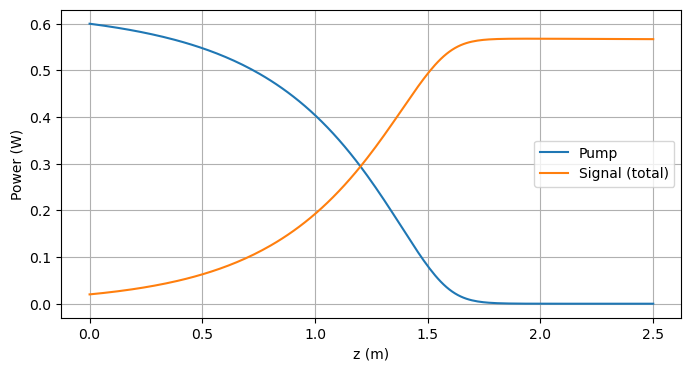

In [6]:
# Reconstruct spectra at the input/output from current uω template and solved Ps
z = sol.t
Pp_z = sol[1, :]
Ps_z = sol[2, :]

Ps_start_vec = spectral_power_bins(Ps_z[1], p)
Ps_end_vec = spectral_power_bins(Ps_z[end], p)

fig = figure(figsize=(8, 4))
plot(z, Pp_z, label="Pump")
plot(z, Ps_z, label="Signal (total)")
xlabel("z (m)")
ylabel("Power (W)")
legend()
grid(true)
fig


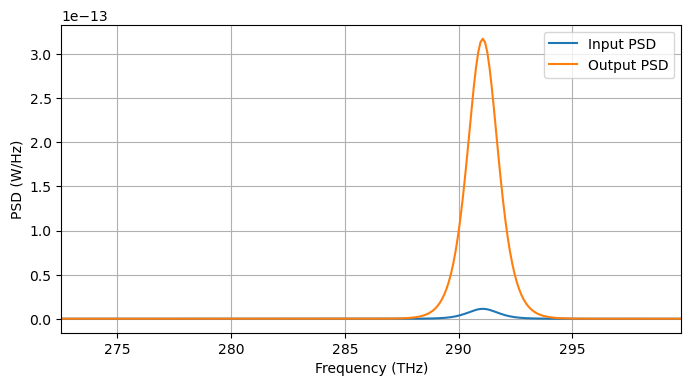

In [7]:
fig = figure(figsize=(8, 4))
plot(p.fs, Ps_start_vec, label="Input PSD")
plot(p.fs, Ps_end_vec, label="Output PSD")
xlim(c / 1100 * 1e-12 * 1e9, c / 1000 * 1e-12 * 1e9)
xlabel("Frequency (THz)")
ylabel("PSD (W/Hz)")
legend()
grid(true)
fig
